Pyroclast: Scalable Geophysics Models
https://github.com/MarcelFerrari/Pyroclast

File: scripts/benchmarks/plot_results.ipynb
Description: File contains code blocks to plot results of benchmark.

Author: Alexander Sotoudeh
Copyright (c) 2024 Marcel Ferrari.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at https://mozilla.org/MPL/2.0/.
# Plotting Notebook.

Subsequent code frame loads all important variables for us to play with

In [12]:
import matplotlib.pyplot
import matplotlib.pyplot as plt
import seaborn as sns

from benchmark.benchmark_validators import BenchmarkRun
from benchmark.config import get_config, BenchmarkConfig
from benchmark.results_processing import load_benchmark_run, create_dataframe, print_statistics

# Get the config from the config factory. (If you don't have a config, consider instantiating a config object here)
# config = BenchmarkConfig(...)
config = BenchmarkConfig(results_store="/home/alisot2000/Polybox/S8/Thesis/benchmark-results/piora-2/",
                         plot_store="/home/alisot2000/Polybox/S8/Thesis/benchmark-results/laptop/plots/"

)

# filename = "2025-06-09/pcbm_20250609-160559_YfMFhLG8S70lT0b0uyjIbpQ5LO5mUeqes8VT9ZIhjFs=.json"

# Inline VS No Inline No Burn in. Algo RB_GS
# filename = "2025-06-12/pcbm_20250612-090840_W_OGndEVkfDbsBaitgK_DLwbQpkxDbD6LKJ2Mg5P25k=.json"

# Inline VS No Inline Burn In Algo RB_GS
# filename = "2025-06-13/pcbm_20250613-133542_ysNOGFiq8dXaph0kQ7vASjTpXfW_8mw05zNDtmZgRo8=.json"

# rb_gs vx gs vs jacobi
# filename = "2025-06-14/pcbm_20250614-205441_rFJAmJMqkKWMDI-NyoZEp7L2EgeQ2NJ5HhVfje20d-U=.json"

# rb_gs vs gs vs jacobi
# filename = "2025-06-14/pcbm_20250614-212726_5vzYE8r6XVjNk5sBQG0KQAPFk7jeD6F2SsEqKI2dvvI=.json"

# rb_gs vs gs vs jacobi
# filename = "2025-06-14/pcbm_20250614-220618_uORoarKSf1VlnYbxYg_RiMK57u-Kt6uGBjL8UAw9cXM=.json"

# filename = "2025-06-13/pcbm_20250613-140721_Lxkir43FCJ3g-AEV-cgyNdufuv_h3hSQR8QzcOAMFJw=.json"

# filename = "2025-09-30/pcbm_20250930-230702_8tjolk-RZe829SxbPtZI7nQDu-ZOF5ylNETB0HcTgek=.json"
# filename = "2025-10-01/pcbm_20251001-090035_YKoA3veGf90BKwRD6vQB_JE0sFrgqhaF95gQUWrFBJ8=.json"
# filename = "2025-10-01/pcbm_20251001-110252_xFJmMV3-BqHIF_96kcnrcriwujK-08j34m-Fn10hxyY=.json"
# filename = "2025-10-01/pcbm_20251001-161500_MNC87D6_C47n1M9M1kfs63Qi5ONY8XpYO-FBA4GSOFU=.json"
# filename = "2025-11-28/pcbm_20251128-162928_ihIXBVylhnpCmIxS5QC1MbGf-Tvbvlb-PJ_Xyg3ndmc=.json"
filename = "2025-11-28/pcbm_20251128-180932_L6TSXrtPYTFGupAmnceDxMSJeO89H5pAJI0KEEVmwmA=.json"
bmr: BenchmarkRun = load_benchmark_run(config=config, path=filename)
bmr_dtf = create_dataframe(bmr)
bmr_dtf = bmr_dtf.query("nx > 64 and ny > 64")

# Set interactive plotting mode
matplotlib.pyplot.ion()

Prepare some common plots

In [13]:
# Module VS Runtimeny:
bmr_dtf["group-cpu-nx-ny"] = bmr_dtf.apply(lambda row: f"cpu:{row.cpu_count} dim:{row.nx} x {row.ny}", axis=1)
bmr_dtf["group-module-nx-ny"] = bmr_dtf.apply(lambda row: f"module:{row.module} dim:{row.nx} x {row.ny}", axis=1)
bmr_dtf["dim"] = bmr_dtf.apply(lambda row: f"dim: {row.nx} x {row.ny}", axis=1)
bmr_dtf["group-module-cpu"] = bmr_dtf.apply(lambda row: f"module:{row.module} cpu:{row.cpu_count}", axis=1)


In [14]:
_ = print_statistics(run=bmr)

Benchmark Results of Smoother Benchmark
Module               cpu_count     nx     ny    runtime std:    runtime avg    runtime std norm:    runtime avg norm    number of samples
-----------------  -----------  -----  -----  --------------  -------------  -------------------  ------------------  -------------------
jacobi_fuse_cache           32  16384  16384     0.222944       0.785063             4.15265e-10         1.46229e-09                   15
jacobi_fuse_cache           32  16384  16384     0.218009       0.763588             4.06074e-10         1.42229e-09                   15
jacobi_fuse_cache           32  16384  16384     0.224405       0.725273             4.17987e-10         1.35093e-09                   15
jacobi_fuse_cache           32  16384  16384     0.226601       0.688755             4.22077e-10         1.28291e-09                   15
jacobi_fuse_cache           32  16384  16384     0.226445       0.663481             4.21786e-10         1.23583e-09                

In [15]:
print(bmr_dtf.columns)
cache_size = list(set(bmr_dtf["cache_bs_1"]))
cache_size.sort()
print(cache_size)


Index(['cpu_count', 'module', 'benchmark_type', 'max_iter', 'nx', 'ny',
       'cache_bs_1', 'cache_bs_2', 'iter_unrol', 'sample', 'duration',
       'normalized_duration', 'name', 'group-cpu-nx-ny', 'group-module-nx-ny',
       'dim', 'group-module-cpu'],
      dtype='object')
[16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 64, 68, 72, 76, 80, 84, 88, 92, 96, 100, 104, 108, 112, 116, 120, 124, 128, 144, 160, 176, 192, 208, 224, 240, 256, 272, 288, 304, 320, 336, 352, 368, 384, 400, 416, 432, 448, 464, 480, 496, 512, 528, 544, 560, 576, 592, 608, 624, 640, 656, 672, 688, 704, 720, 736, 752, 768, 784, 800, 816, 832, 848, 864, 880, 896, 912, 928, 944, 960, 976, 992, 1008, 1024, 1040, 1056, 1072, 1088, 1104, 1120, 1136, 1152, 1168, 1184, 1200, 1216, 1232, 1248, 1264, 1280, 1296, 1312, 1328, 1344, 1360, 1376, 1392, 1408, 1424, 1440, 1456, 1472, 1488, 1504, 1520]


0         16
1         16
2         16
3         16
4         16
        ... 
3475    1520
3476    1520
3477    1520
3478    1520
3479    1520
Name: cache_bs_1, Length: 3480, dtype: int64


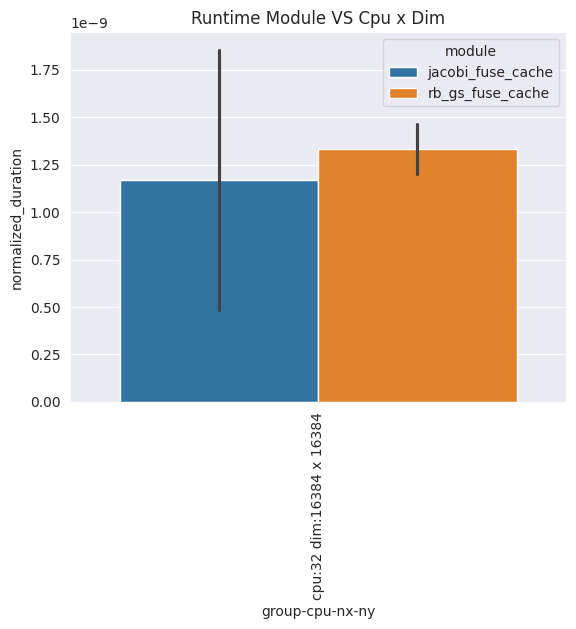

In [16]:
print(bmr_dtf["cache_bs_1"])
plt.xticks(rotation=90)

plot = sns.barplot(bmr_dtf, x="group-cpu-nx-ny", y="normalized_duration", hue="module", errorbar="sd").set_title("Runtime Module VS Cpu x Dim")
fig = plot.get_figure()

# fig.savefig(f"Test.svg")


Text(0.5, 1.0, 'Runtime Module VS Dim, CPU=16')

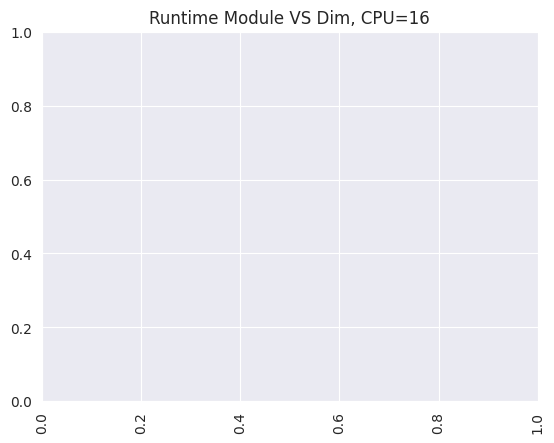

In [17]:
plt.xticks(rotation=90)
sns.barplot(bmr_dtf.query("cpu_count == 16"), x="dim", y="normalized_duration", hue="module").set_title("Runtime Module VS Dim, CPU=16")


Text(0.5, 1.0, 'Runtime Module VS Dim, CPU=8')

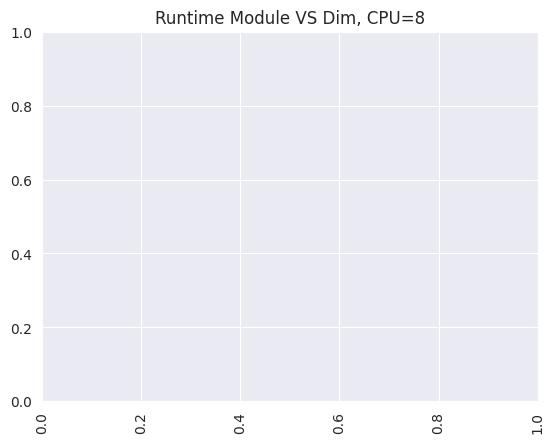

In [18]:
plt.xticks(rotation=90)
sns.barplot(bmr_dtf.query("cpu_count == 8"), x="dim", y="normalized_duration", hue="module").set_title("Runtime Module VS Dim, CPU=8")


Text(0.5, 1.0, 'Runtime CPU Count VS Module x Dim')

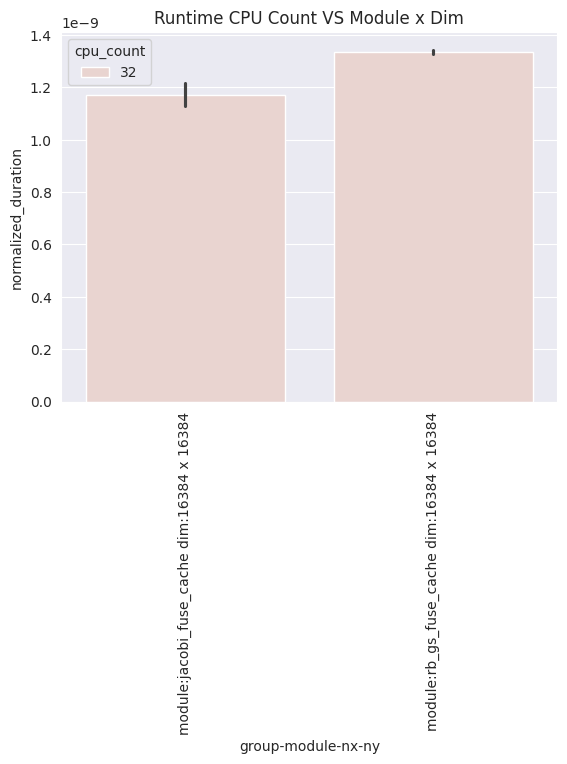

In [19]:
plt.xticks(rotation=90)
sns.barplot(bmr_dtf, x="group-module-nx-ny", y="normalized_duration", hue="cpu_count").set_title("Runtime CPU Count VS Module x Dim")
# sns.catplot(bmr_dtf, x="group-module-nx-ny", y="normalized_duration", col="cpu_count", kind="box")

Text(0.5, 1.0, 'Runtime Module x CPU vs Dim')

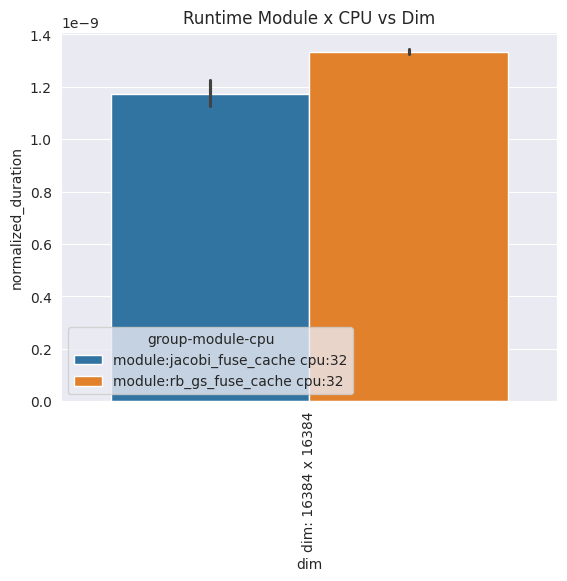

In [20]:
plt.xticks(rotation=90)
sns.barplot(bmr_dtf, x="dim", y="normalized_duration", hue="group-module-cpu").set_title("Runtime Module x CPU vs Dim")

Text(0.5, 1.0, 'Runtime Dim VS Module x CPU ')

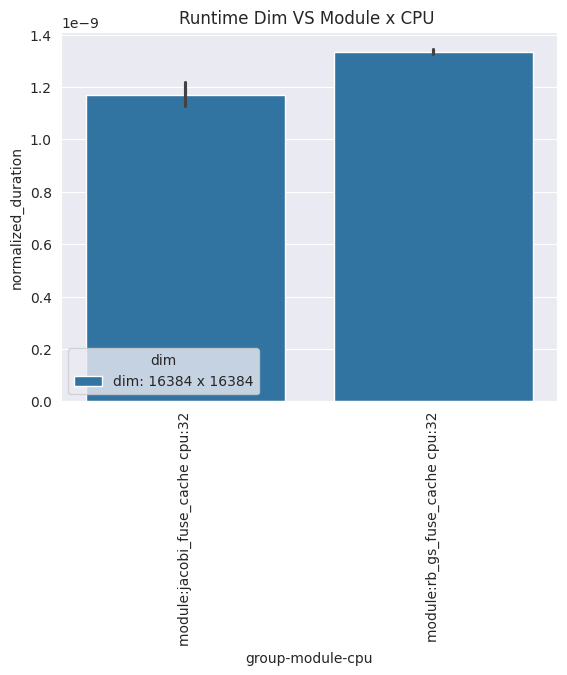

In [21]:
plt.xticks(rotation=90)
sns.barplot(bmr_dtf, x="group-module-cpu", y="normalized_duration", hue="dim").set_title("Runtime Dim VS Module x CPU ")

<Axes: xlabel='cache_bs_1', ylabel='normalized_duration'>

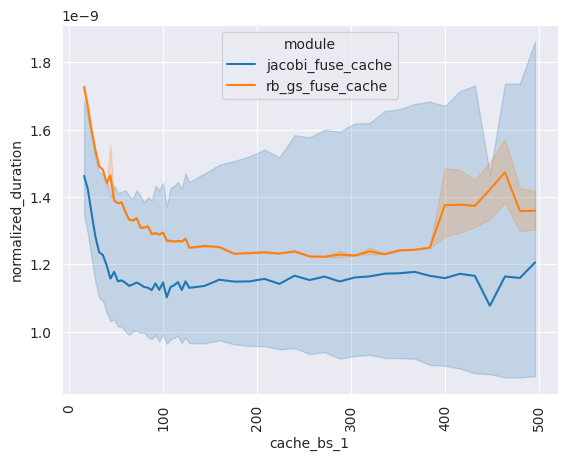

In [22]:
plt.xticks(rotation=90)
sns.lineplot(bmr_dtf, x="cache_bs_1", y="normalized_duration", hue="module")
